In [209]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [196]:
def read_file(filename):
    return pd.read_csv(filename)

df = read_file('result_large_prime.csv')

In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   threads       84 non-null     int64  
 1   num_iters     84 non-null     int64  
 2   outside_work  84 non-null     int64  
 3   n             84 non-null     int64  
 4   tas_ms        84 non-null     float64
 5   ttas_ms       84 non-null     float64
 6   mcs_ms        84 non-null     float64
dtypes: float64(3), int64(4)
memory usage: 4.7 KB


In [198]:
df.describe()

,threads,num_iters,outside_work,n,tas_ms,ttas_ms,mcs_ms
count,84.000000,84.0,84.00000,84.0,84.000000,84.000000,84.000000
mean,9.000000,1000.0,2.25000,997.0,18.348093,17.459338,23.061219
std,6.780553,0.0,1.93182,0.0,13.896033,12.945906,25.230850
min,1.000000,1000.0,0.00000,997.0,2.590100,1.676500,1.619600
25%,2.000000,1000.0,0.75000,997.0,6.316525,6.059825,6.477350
50%,8.000000,1000.0,2.00000,997.0,14.472550,14.028950,14.631250
75%,16.000000,1000.0,3.50000,997.0,28.703775,26.355825,30.059300
max,20.000000,1000.0,5.00000,997.0,49.134600,44.463000,128.685000


## When n = 10000

In [199]:
df_10000 = df #df[df['n'] == 100]
df_10000.describe()

,threads,num_iters,outside_work,n,tas_ms,ttas_ms,mcs_ms
count,84.000000,84.0,84.00000,84.0,84.000000,84.000000,84.000000
mean,9.000000,1000.0,2.25000,997.0,18.348093,17.459338,23.061219
std,6.780553,0.0,1.93182,0.0,13.896033,12.945906,25.230850
min,1.000000,1000.0,0.00000,997.0,2.590100,1.676500,1.619600
25%,2.000000,1000.0,0.75000,997.0,6.316525,6.059825,6.477350
50%,8.000000,1000.0,2.00000,997.0,14.472550,14.028950,14.631250
75%,16.000000,1000.0,3.50000,997.0,28.703775,26.355825,30.059300
max,20.000000,1000.0,5.00000,997.0,49.134600,44.463000,128.685000


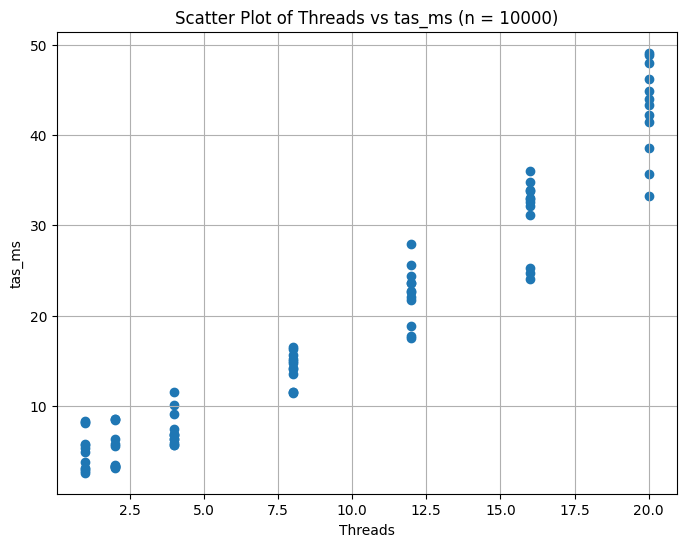

In [200]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df_10000['threads'], df_10000['tas_ms'])
plt.title('Scatter Plot of Threads vs tas_ms (n = 10000)')
plt.xlabel('Threads')
plt.ylabel('tas_ms')
plt.grid(True)
plt.show()

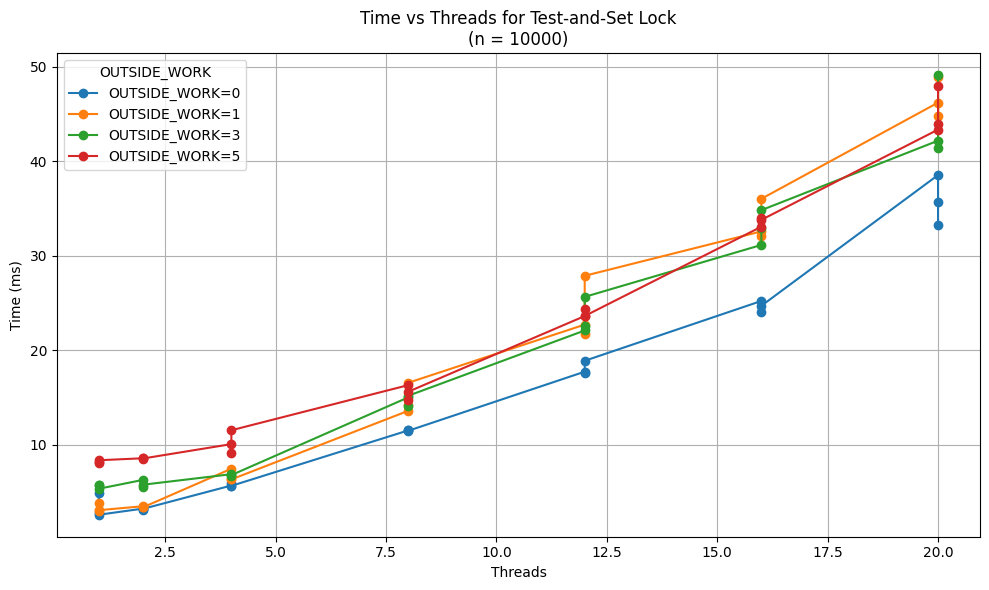

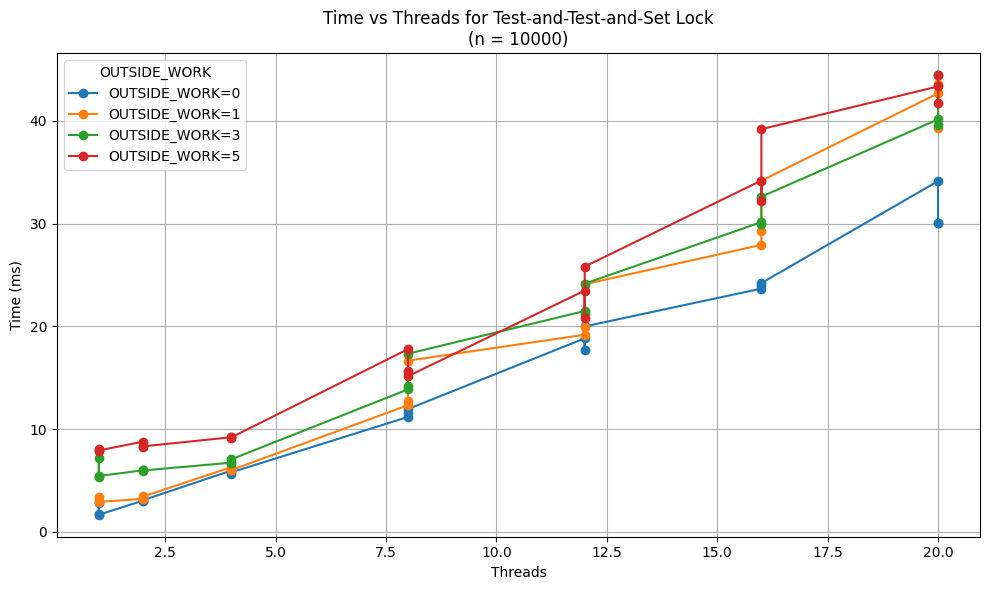

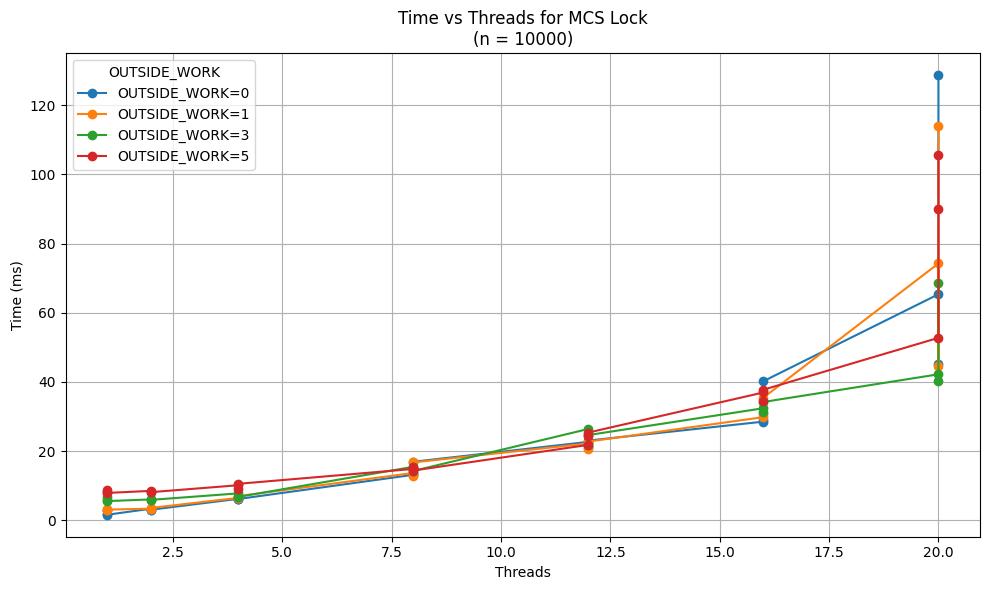

In [201]:
# Plot Time vs Threads for each lock type, with separate curves for each outside_work

import seaborn as sns

locks = ['tas_ms', 'ttas_ms', 'mcs_ms']
lock_names = {'tas_ms': 'Test-and-Set', 'ttas_ms': 'Test-and-Test-and-Set', 'mcs_ms': 'MCS'}
outside_works = sorted(df_10000['outside_work'].unique())

for lock in locks:
    plt.figure(figsize=(10,6))
    for out in outside_works:
        df_group = df_10000[df_10000['outside_work'] == out]
        # Sort by threads for clearer lines
        df_group = df_group.sort_values('threads')
        plt.plot(df_group['threads'], df_group[lock], marker='o', label=f'OUTSIDE_WORK={out}')
    plt.title(f'Time vs Threads for {lock_names[lock]} Lock\n(n = 10000)')
    plt.xlabel('Threads')
    plt.ylabel('Time (ms)')
    plt.legend(title='OUTSIDE_WORK')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Analyze PERFORMANCE among locking mechanism

#### Result with true prime numbers

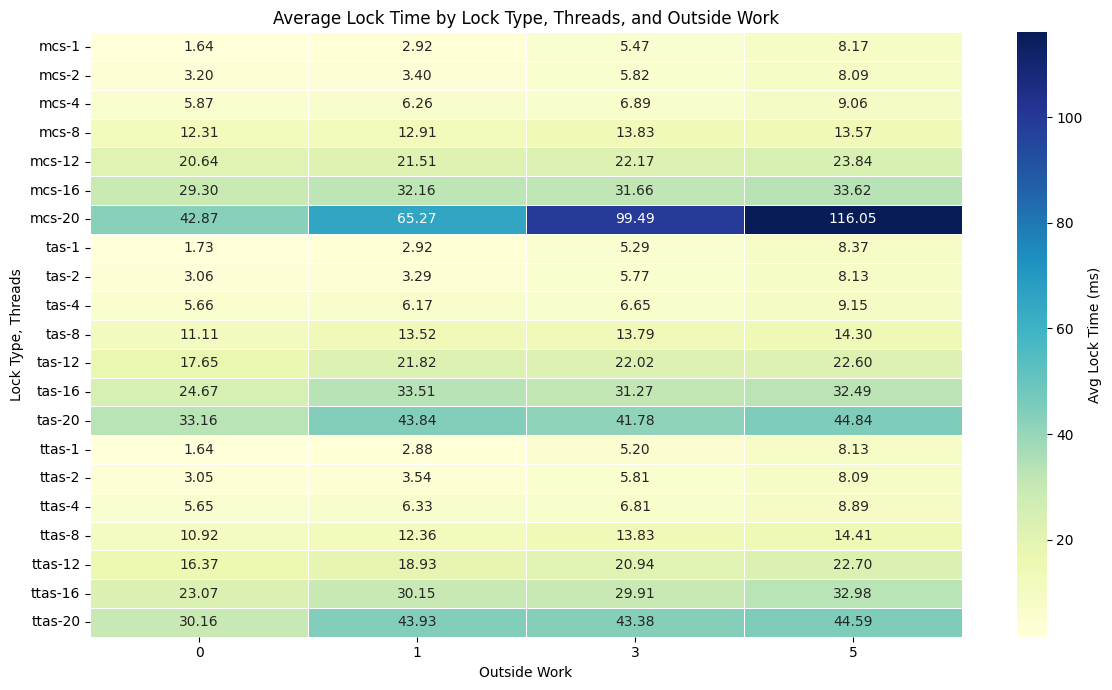

In [214]:
import pandas as pd

# Filter for outside_work <= 3 and threads <= 20
df_true_prime = read_file("result_large_prime.csv")

# Prepare 'lock', 'time' format for easier analysis, then concatenate for all lock types
frames = []
for lock in ['tas_ms', 'ttas_ms', 'mcs_ms']:
    df_tmp = df_true_prime[['threads', 'outside_work', lock]].copy()
    df_tmp = df_tmp.rename(columns={lock: 'time'})
    df_tmp['lock'] = lock.replace('_ms', '')
    frames.append(df_tmp)

df_long = pd.concat(frames, ignore_index=True)

# Calculate min, median, max, avg by lock and threads (for small contention)
min_time = df_long.groupby(['lock', 'threads'])['time'].min()
median_time = df_long.groupby(['lock', 'threads'])['time'].median()
max_time = df_long.groupby(['lock', 'threads'])['time'].max()
avg_time = df_long.groupby(['lock', 'threads'])['time'].mean()

# Present as DataFrame for easier inspection:
stats_df = pd.DataFrame({
    'min': min_time,
    'median': median_time,
    'max': max_time,
    'avg': avg_time
}).reset_index()

# display(stats_df)

# Create a pivot table: rows=(lock,threads), columns=outside_work, values=time (avg)
pivot_table = pd.pivot_table(
    df_long, 
    values='time',
    index=['lock', 'threads'],
    columns=['outside_work'],
    aggfunc='mean'
)

# show chart

plt.figure(figsize=(12, 7))
sns.heatmap(
    pivot_table, 
    annot=True, 
    fmt=".2f", 
    cmap="YlGnBu", 
    linewidths=.5, 
    cbar_kws={'label': 'Avg Lock Time (ms)'}
)
plt.title('Average Lock Time by Lock Type, Threads, and Outside Work')
plt.ylabel('Lock Type, Threads')
plt.xlabel('Outside Work')
plt.tight_layout()
plt.show()




#### High contention (higher number of threads + number of iterations)
- NUM_OF_ITERS = 100000
- THREAD_COUNTS[] = {17,18,19,20};
- OUTSIDE_WORKS[] = {0};
- NS[] = {  13, 17, 29, 51 };

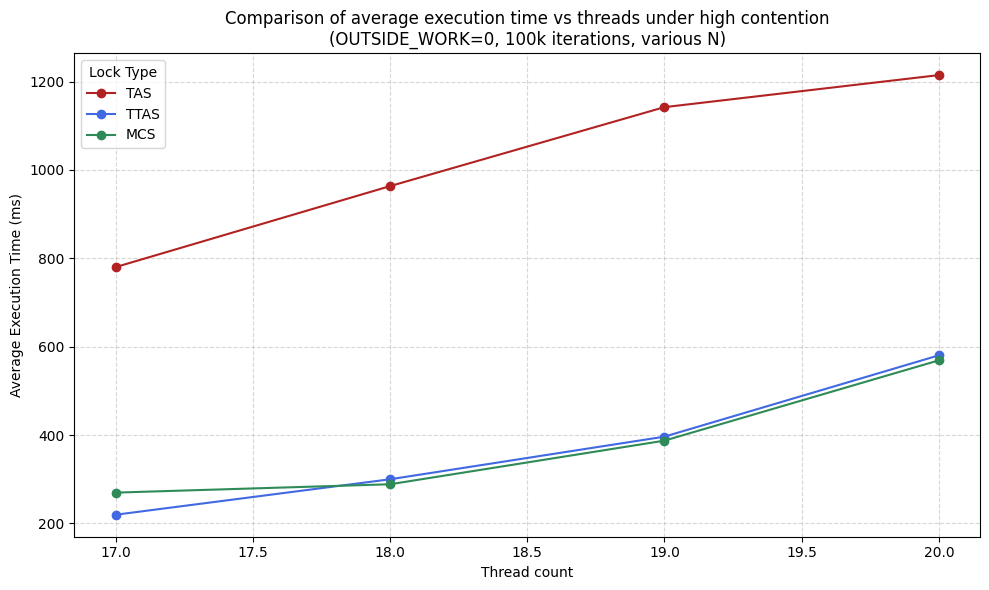

In [ ]:
df_prime_mcs = read_file("result_prime_mcs.csv")

# Compare the average lock acquisition time for each lock type as the number of threads increases (for OUTSIDE_WORKS==0)
df_plot = df_prime_mcs[df_prime_mcs['outside_work'] == 0].copy()

locks = ['tas', 'ttas', 'mcs']
colors = {'tas': 'firebrick', 'ttas': 'royalblue', 'mcs': 'seagreen'}

# Calculate the average lock time for each lock type at each thread count
avg_time_by_lock = (
    df_plot
    .groupby('threads')[[f"{lock}_ms" for lock in locks]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
for lock in locks:
    plt.plot(
        avg_time_by_lock['threads'], 
        avg_time_by_lock[f'{lock}_ms'], 
        marker='o', 
        label=f"{lock.upper()}",
        color=colors[lock]
    )

plt.title("Comparison of average execution time vs threads under high contention\n(OUTSIDE_WORK=0, 100k iterations, various N)")
plt.xlabel("Thread count")
plt.ylabel("Average Execution Time (ms)")
plt.legend(title="Lock Type")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Performance and Scalability analysis

In [240]:
df = read_file("result.csv")

#### 1. Low thread + 0 outside work + low prime number
- Baseline overhead of each lock with no outside noise.

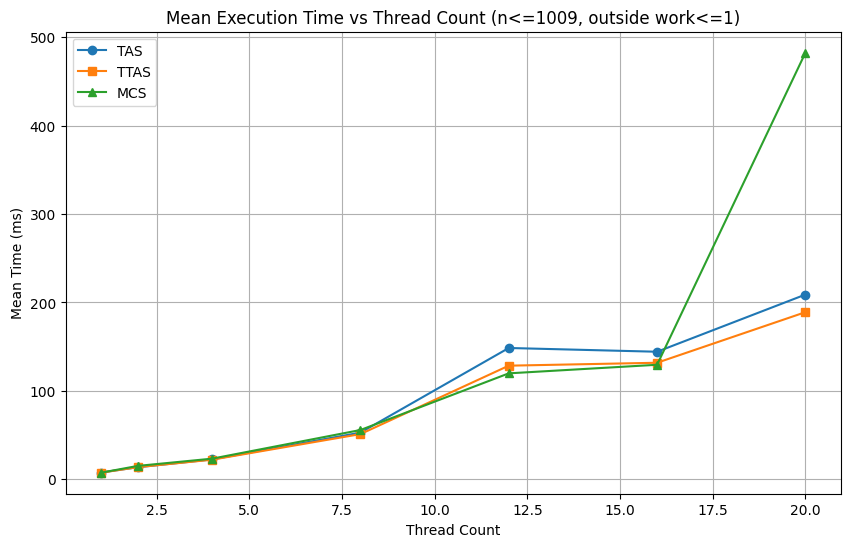

In [248]:
fixed_n = 1009  # one of the low primes used in your data
fixed_outside_work = 1

# Filter and group, then compute the mean for each lock at every thread count
df_scalability = df[
    (df["n"] <= fixed_n) &
    (df["outside_work"] <= fixed_outside_work)
].groupby("threads")[["tas_ms", "ttas_ms", "mcs_ms"]].mean().reset_index().sort_values("threads")

plt.figure(figsize=(10, 6))
plt.plot(df_scalability["threads"], df_scalability["tas_ms"], marker='o', label="TAS")
plt.plot(df_scalability["threads"], df_scalability["ttas_ms"], marker='s', label="TTAS")
plt.plot(df_scalability["threads"], df_scalability["mcs_ms"], marker='^', label="MCS")

plt.title(f"Mean Execution Time vs Thread Count (n<={fixed_n}, outside work<={fixed_outside_work})")
plt.xlabel("Thread Count")
plt.ylabel("Mean Time (ms)")
plt.legend()
plt.grid(True)
plt.show()

#### 2. High thread + 0 outside work + low prime number
- The MCS "Win": Max contention and high traffic.

#### 3. Low thread + 0 outside work + High prime number
- Does a long CS make the lock type less relevant?

#### 4.High thread + 0 outside work + High prime number
- 

#### 5. Low thread + 5 outside work + Low prime number
- Scenario where TAS might beat MCS due to lower overhead.

#### 6. High thread + 5 outside work + Low prime number
- Does the interconnect still choke even with outside work?

#### 7. Low thread + 5 outside work + High prime number
- Low-load baseline for long-running critical sections.

#### 8. High thread + 5 outside work + High prime number
- Scalability test under "realistic" staggered arrival rates.

### Experiment Analysis

In [235]:
df = read_file("result.csv")

#### 1. Scalability:
- How the performance changes with different thread count

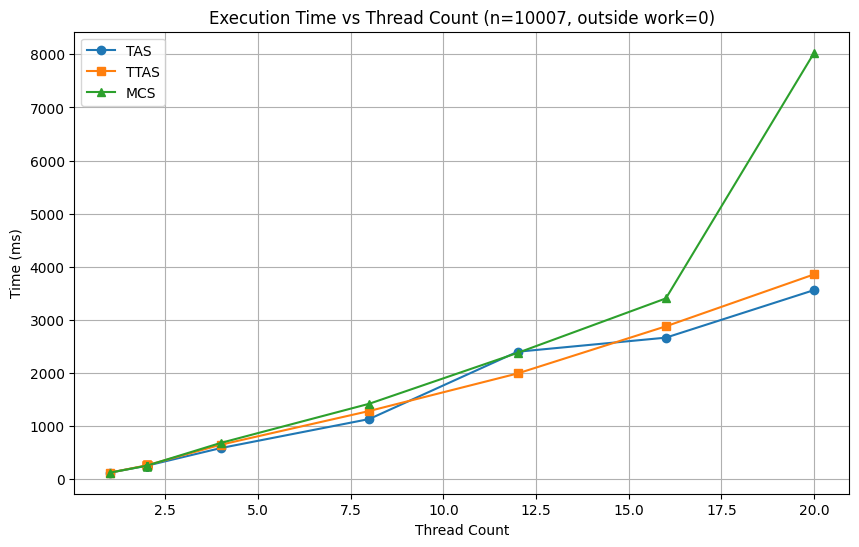

In [249]:
fixed_n = 10007  # one of the low primes used in your data
fixed_outside_work = 0

df_scalability = df[
    (df["n"] == fixed_n) &
    (df["outside_work"] == fixed_outside_work)
].sort_values("threads")

plt.figure(figsize=(10, 6))
plt.plot(df_scalability["threads"], df_scalability["tas_ms"], marker='o', label="TAS")
plt.plot(df_scalability["threads"], df_scalability["ttas_ms"], marker='s', label="TTAS")
plt.plot(df_scalability["threads"], df_scalability["mcs_ms"], marker='^', label="MCS")

plt.title(f"Execution Time vs Thread Count (n={fixed_n}, outside work={fixed_outside_work})")
plt.xlabel("Thread Count")
plt.ylabel("Time (ms)")
plt.legend()
plt.grid(True)
plt.show()

### 2. Contention
- How the performance changes with different outside work? (Sensitivity to arrival)

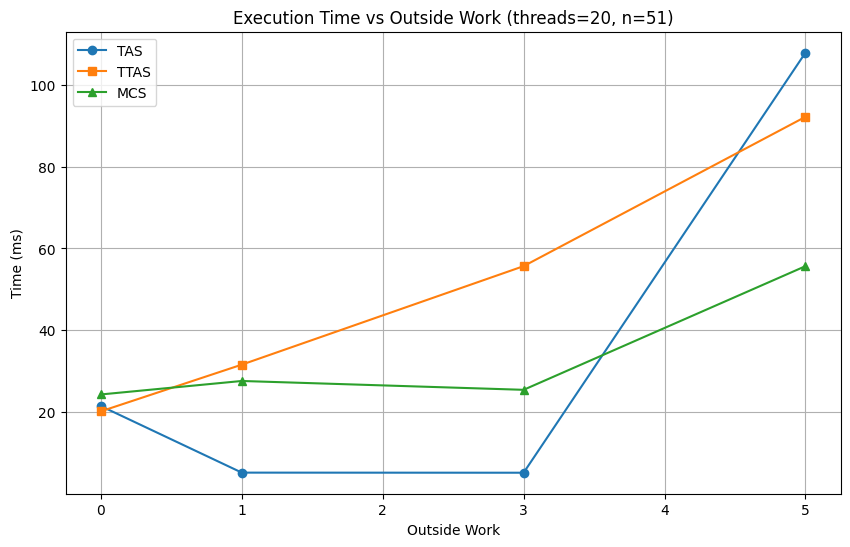

In [254]:
# Analyze contention: performance vs. outside_work at fixed thread count and n

fixed_threads = 20  # choose a representative thread count present in your data, e.g., 8
fixed_n = 51    # keep n same as above for consistency

df_contention = df[
    (df["threads"] == fixed_threads) &
    (df["n"] == fixed_n)
].sort_values("outside_work")

plt.figure(figsize=(10, 6))
plt.plot(df_contention["outside_work"], df_contention["tas_ms"], marker='o', label="TAS")
plt.plot(df_contention["outside_work"], df_contention["ttas_ms"], marker='s', label="TTAS")
plt.plot(df_contention["outside_work"], df_contention["mcs_ms"], marker='^', label="MCS")

plt.title(f"Execution Time vs Outside Work (threads={fixed_threads}, n={fixed_n})")
plt.xlabel("Outside Work")
plt.ylabel("Time (ms)")
plt.legend()
plt.grid(True)
plt.show()

#### 3. Workload
- How the overall performance changes with different the critical section workload?

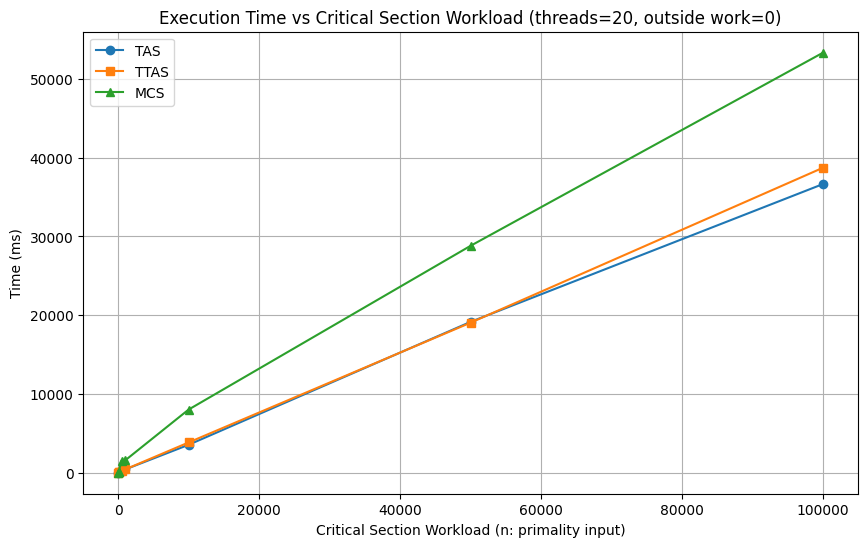

In [239]:
# Analyze workload: performance vs. n (the "critical section workload") at fixed thread count and outside_work

fixed_threads = 20  # keep consistent with earlier analysis
fixed_outside_work = 0  # minimal outside work to isolate impact of prime complexity

df_workload = df[
    (df["threads"] == fixed_threads) &
    (df["outside_work"] == fixed_outside_work)
].sort_values("n")

plt.figure(figsize=(10, 6))
plt.plot(df_workload["n"], df_workload["tas_ms"], marker='o', label="TAS")
plt.plot(df_workload["n"], df_workload["ttas_ms"], marker='s', label="TTAS")
plt.plot(df_workload["n"], df_workload["mcs_ms"], marker='^', label="MCS")

plt.title(f"Execution Time vs Critical Section Workload (threads={fixed_threads}, outside work={fixed_outside_work})")
plt.xlabel("Critical Section Workload (n: primality input)")
plt.ylabel("Time (ms)")
plt.legend()
plt.grid(True)
plt.show()